# Практическое задание №5

Используйте данные из файла **advertising.csv** с информацией о клиентах интернет-магазина.

В нём содержаться следующие переменные:

| Название переменной | Описание переменной
|:-------------------:|:------------------:|
| Daily Time Spent on Site | consumer time on site in minutes |
| Age | cutomer age in years |
| Area Income | Avg. Income of geographical area of consumer |
| Daily Internet Usage | Avg. minutes a day consumer is on the internet |
| Ad Topic Line | Headline of the advertisement |
| City | City of consumer |
| Male | Whether or not consumer was male |
| Country |	Country of consumer |
| Timestamp | Time at which consumer clicked on Ad or closed window |
| Clicked on Ad | 0 or 1 indicated clicking on Ad |


Задача - создать модель, которая будет предсказывать, нажмет ли интернет-пользователь на рекламу, на основе характеристик этого пользователя.

Выполните, пожалуйста, следующие задания.

# Разведочный анализ данных

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

In [12]:
df = pd.read_csv('advertising.csv')

In [13]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [15]:
df['Clicked on Ad'].value_counts()

,count
Clicked on Ad,
0,500
1,500


Элементов положительного и отрицательного классов одинаковое количество


# 1. Сформулируйте гипотезы, которые будут проверены в ходе исследования.

1. Возраст влияет на то, кликнет ли пользователь на рекламу, скажем, что молодые чаще кликают на рекламу

2. Тот, кот больше сидит в интернете, реже кликает на рекламу

3. Чем дольше человек сидит на сайте, тем выше вероятность, что он кликнет на баннер


4. Чем выше 'Area income' тем выше вероятность, что пользователь кликнет на рекламу

# 2. Постройте модель бинарной логистической регрессии. Зависимая переменная – Clicked on Ad. В качестве предикторов выберите не менее 3 метрических переменных и не менее 2 категориальных переменных. Напишите уравнение регрессии (линейная часть). Охарактеризуйте регрессионную модель. Оцените статическую значимость и предсказательную силу модели. Постройте ROC-кривую и прокомментируйте ее. Рассчитайте площадь под ROC-кривой.

Сделаем категориальную фичу возраст искусственно.

In [16]:
bins = [-float("inf"), 30, 40, float("inf")]
labels = ["age_le_30", "age_31_40", "age_ge_41"]

df["age_group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_dummies = pd.get_dummies(df["age_group"], prefix="", prefix_sep="").astype(int)

df = pd.concat([df, age_dummies], axis=1)

In [17]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad,age_group,age_le_30,age_31_40,age_ge_41
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0,age_31_40,0,1,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0,age_31_40,0,1,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0,age_le_30,1,0,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0,age_le_30,1,0,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0,age_31_40,0,1,0


Выберем следующие переменные
1. Male
2. Daily Time Spent on Site
3. Area Income
4. Daily Internet Usage
5. Age('age_le_30', 'age_31_40')


Проверим связь таргета с выбранными переменными

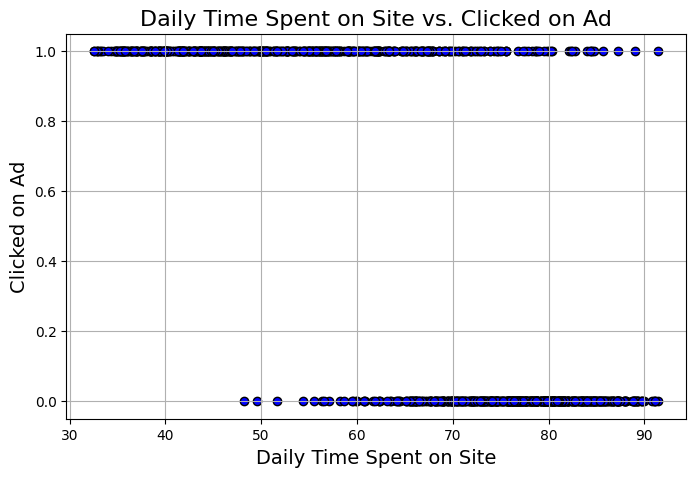

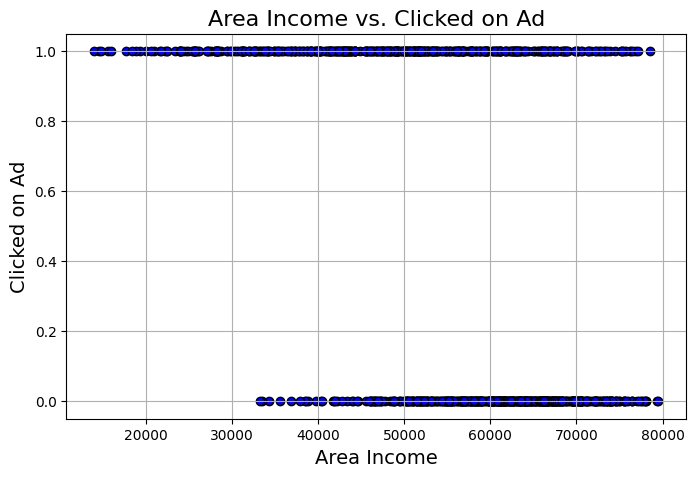

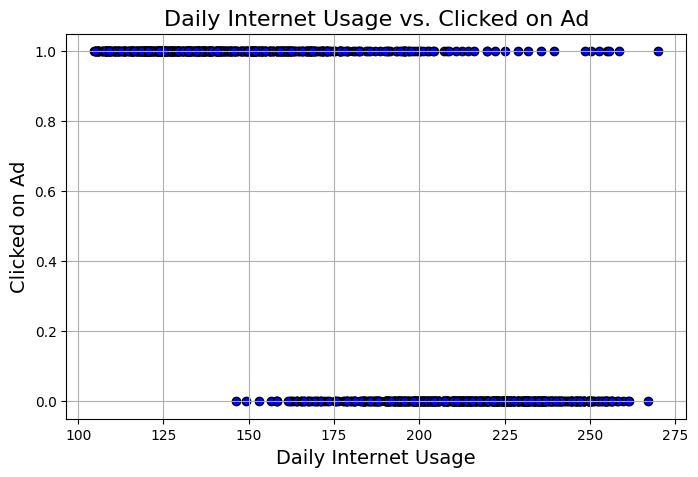

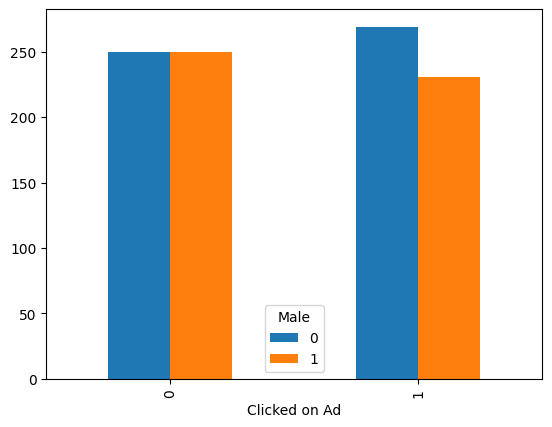

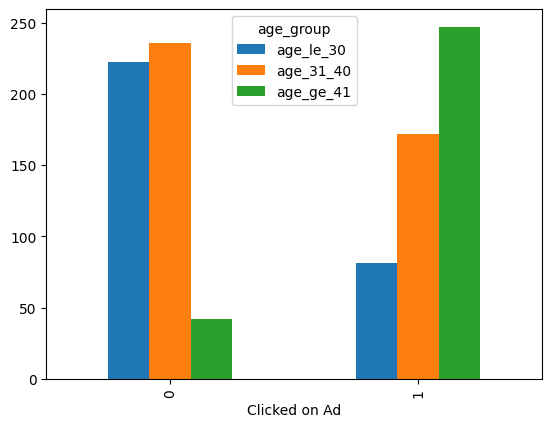

In [18]:
for c in df.columns[0:]:
    if c == 'Daily Time Spent on Site' or c == 'Area Income' or c=='Daily Internet Usage':
        plt.figure(figsize=(8,5))
        plt.title('{} vs. Clicked on Ad'.format(c), fontsize=16)
        plt.scatter(x=df[c], y=df["Clicked on Ad"], color='blue',edgecolor='k')
        plt.grid(True)
        plt.xlabel(c, fontsize=14)
        plt.ylabel('Clicked on Ad', fontsize=14)
        plt.show()
    elif c == 'Male' or c == 'age_group':
        ct = pd.crosstab(df["Clicked on Ad"], df[c])
        ct.plot.bar()

In [19]:
cols = ['Male', 'Daily Time Spent on Site', 'Area Income', 'Daily Internet Usage',
        'age_le_30', 'age_31_40']

metric_cols = ['Daily Time Spent on Site', 'Area Income', 'Daily Internet Usage']

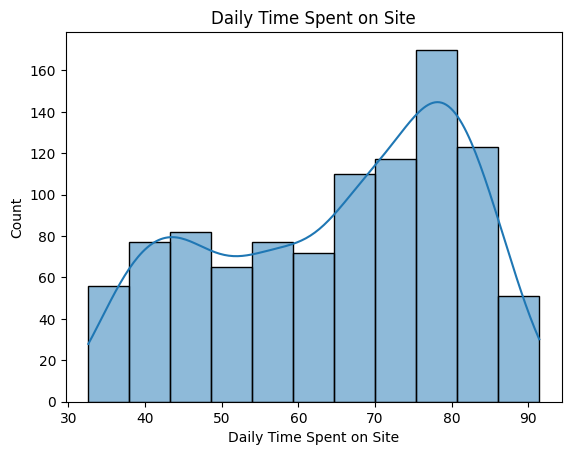

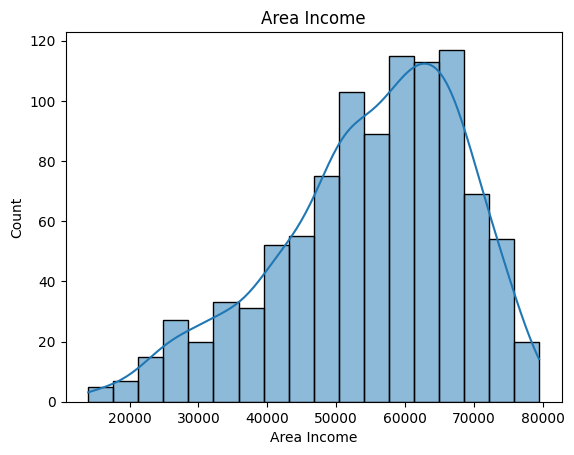

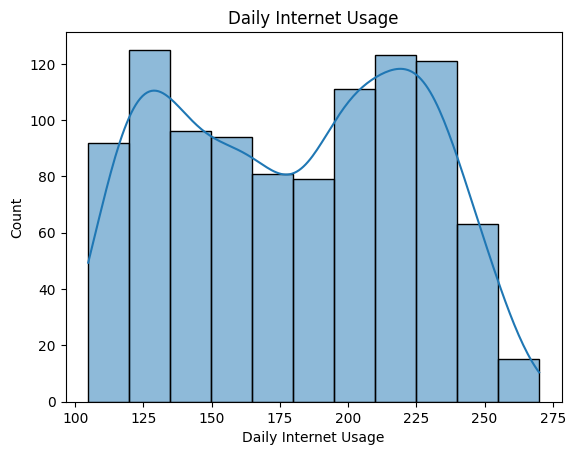

In [20]:
for col in metric_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

У этих признаков не нормальное распределение, поэтому будем для нахождения корреляции использовать коэффицент Спирмана

In [37]:
data_clean = df.dropna()
data_clean[metric_cols].corr(method = "spearman")

,Daily Time Spent on Site,Area Income,Daily Internet Usage
Daily Time Spent on Site,1.000000,0.283134,0.514108
Area Income,0.283134,1.000000,0.339160
Daily Internet Usage,0.514108,0.339160,1.000000


Корреляция в пределах нормы

In [39]:

age_cols = ["age_le_30", "age_31_40", "age_ge_41"]
age_group = df[age_cols].idxmax(axis=1)
ct = pd.crosstab(age_group, df["Male"])
print(ct)

ct_norm = pd.crosstab(age_group, df["Male"], normalize="index")
print(ct_norm)


Male         0    1
row_0              
age_31_40  210  198
age_ge_41  153  136
age_le_30  156  147
Male              0         1
row_0                        
age_31_40  0.514706  0.485294
age_ge_41  0.529412  0.470588
age_le_30  0.514851  0.485149


Категориальные фичи не повторяют друг друга, даные подготовлены и проверены, можно использовать логистическую регрессию

In [38]:
from sklearn.preprocessing import StandardScaler

cols = ['Male', 'Daily Time Spent on Site', 'Area Income', 'Daily Internet Usage',
        'age_le_30', 'age_31_40']

scaler = StandardScaler()

X = df[cols].copy()
X[cols] = scaler.fit_transform(X[cols])

X_const = sm.add_constant(X)
y = df['Clicked on Ad']

model = sm.Logit(y, X_const).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.099756
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:          Clicked on Ad   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      993
Method:                           MLE   Df Model:                            6
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.8561
Time:                        10:38:58   Log-Likelihood:                -99.756
converged:                       True   LL-Null:                       -693.15
Covariance Type:            nonrobust   LLR p-value:                3.473e-253
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        1.4860      0.284      5.229      0.000       0.929

z=1.4860−0.2410⋅Male−2.8306⋅DailyTime−1.6198⋅AreaIncome−2.7657⋅DailyInternet−1.5057⋅age_le30−1.0510⋅age_31−40

где
log((1−p) / p​)=z
где p - вероятность того, что пользователь кликнет на рекламу


## Оценка и характеристика модели

### Качество модели в целом

* **LLR p-value = 3.47e-253** → модель в целом статистически значима (p << 0.05).
  То есть выбранные предикторы реально улучшают объяснение кликов по сравнению с нулевой моделью.
* **Pseudo R-squ. (McFadden) = 0.8561** → очень высокая объясняющая способность для логистической регрессии (модель хорошо отделяет классы).


In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_prob = model.predict(X_const)
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y, y_pred))
print("Confusion matrix:\n", confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))

Accuracy: 0.973
Confusion matrix:
 [[491   9]
 [ 18 482]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       500
           1       0.98      0.96      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



accuracy = 0.973, модель очень хорошо отделяет классы(на обучащей выборке)
То же можно сказать, посмотрев на precision recall and f1-score

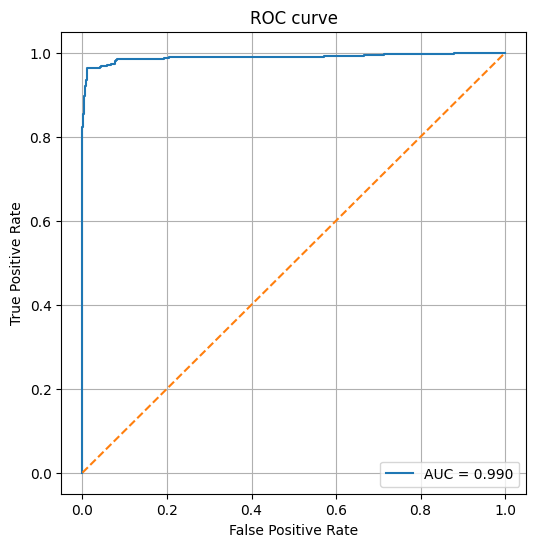

AUC: 0.9895760000000001


In [23]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y, y_prob)
auc = roc_auc_score(y, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid(True)
plt.show()

print("AUC:", auc)


AUC-ROC = 0.99 - очень хороший показатель, модель очень хорошо ранжирует классы, график ROC-кривой лежит сильно выше диагонали

# 3. Оцените статистическую значимость регрессионных коэффициентов. Подробно интерпретируйте особенности взаимосвязи между каждым из предикторов и зависимой переменной на основе значений регрессионных коэффициентов.

### Значимость предикторов (p-value)

**Значимы (p < 0.05):**

* `Daily Time Spent on Site` (coef −2.8306, p=0.000)
* `Area Income` (coef −1.6198, p=0.000)
* `Daily Internet Usage` (coef −2.7657, p=0.000)
* `age_le_30` (coef −1.5057, p=0.000)
* `age_31_40` (coef −1.0510, p=0.000)

**Незначим:**

* `Male` (coef −0.2410, p=0.211) → пол не даёт вклад при контроле остальных переменных.

---

## Интерпретация коэффициентов

### Метрические предикторы

У всех трёх метрических коэффициенты **отрицательные**:

* Чем **больше ежедневное время на сайте**, тем **меньше шанс клика**.
* Чем **выше доход района (Area Income)**, тем **меньше вероятность клика**.
* Чем **больше дневное использование интернета**, тем **ниже вероятность клика**.

Это интерпретируется как снижение log-odds клика при росте этих переменных.

### Возрастные группы (относительно базовой)

Базовая группа — **41+**

* `age_le_30`: coef −1.5057 → люди **до 30** кликают **значимо реже**, чем 41+.
* `age_31_40`: coef −1.0510 → люди **31–40** также кликают **реже**, чем 41+.

То есть по сравнению с 41+ обе младшие группы имеют меньшую вероятность клика.

# 4. Проведите диагностику модели (проверьте остатки, оцените мультиколлинартность). Проведите кросс-валидацию модели и опишите полученные результаты.

In [24]:
p = stats.kstest(model.resid_generalized, 'norm', args=(model.resid_generalized.mean(), model.resid_generalized.std())).pvalue
print('P-value: {:.3f}'.format(p))

P-value: 0.000


In [25]:
import seaborn as sns

<Axes: ylabel='Density'>

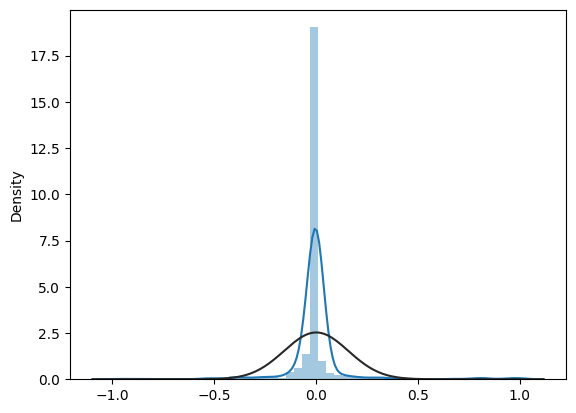

In [27]:
sns.distplot(model.resid_generalized, fit=stats.norm)

Распределение остатков отличается от нормального распределения.

In [28]:
vifs = np.array([vif(model.model.exog, i) for i in range(model.model.exog.shape[1])])
vif_df = pd.DataFrame()
vif_df['VIF'] = vifs[1:]
vif_df['Features'] = model.params.index[1:]
vif_df.sort_values(by=['VIF'])

,VIF,Features
0,1.002451,Male
2,1.171325,Area Income
1,1.455422,Daily Time Spent on Site
3,1.519889,Daily Internet Usage
5,1.616124,age_31_40
4,1.686449,age_le_30


Нет значений VIF, превышающих 10. Проблема мультиколлинеарности отсутствует

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [30]:
X_cv = df[['Male','Daily Time Spent on Site','Area Income','Daily Internet Usage',
           'age_le_30','age_31_40']]
y_cv = df['Clicked on Ad']

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = cross_val_score(pipe, X_cv, y_cv, cv=cv, scoring="roc_auc")
acc_scores = cross_val_score(pipe, X_cv, y_cv, cv=cv, scoring="accuracy")

print("CV ROC-AUC: mean =", auc_scores.mean(), " std =", auc_scores.std())
print("CV Accuracy: mean =", acc_scores.mean(), " std =", acc_scores.std())

CV ROC-AUC: mean = 0.9895400000000001  std = 0.004831811254591763
CV Accuracy: mean = 0.9719999999999999  std = 0.014696938456699083


По результатам кросс валидации средний ROC-AUC = 0.99. Модель работает очень хорошо.

# 5. Сформулируйте общие содержательные выводы по результатам регрессионного анализа данных (общие содержательные выводы - это не копирование того, что вы писали в предыдущих пунктах). Какие результаты анализа данных для вас оказались очевидными, а какие неожиданными?

1.   Возраст влияет на то, кликнет ли пользователь на рекламу, скажем что молодые чаще кликают на рекламу.
Гипотеза не оправдалась, все получилось наоборот, старые чаще кликают на рекламу
2.   Тот, кот больше сидит в интернете, реже кликает на рекламу.
Гипотеза подтвердилась, это и логично, он видит больше реклам, значит на одну конкретную кликает реже
3.  Чем дольше человек сидит на сайте, тем выше вероятность, что он кликнет на баннер.
Гипотеза опровергнута, работает наоборот, чем больше человек сидит на сайте, тем ниже шанс того, что он кликнет на баннер
4.  Чем выше 'Area income' тем выше вероятность, что пользователь кликнет на рекламу.
Гипотеза опровергнута, это работает наоборот.



# Дополнительная работа

В качестве доп задания обучим модели другим, более сложным способом, будем использовать Случайный лес и градиентный бустинг

In [33]:
from sklearn.model_selection import train_test_split

X = df[['Male','Daily Time Spent on Site','Area Income','Daily Internet Usage',
        'age_le_30','age_31_40']]
y = df['Clicked on Ad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:,1]
rf_pred = (rf_prob >= 0.5).astype(int)

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest ROC-AUC: 0.9912
Random Forest Accuracy: 0.975
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       100
           1       0.97      0.98      0.98       100

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



ROC-AUC и accuracy получились больше, чем у обычной логистической регрессии.

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

gb_prob = gb.predict_proba(X_test)[:,1]
gb_pred = (gb_prob >= 0.5).astype(int)

print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, gb_prob))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))


Gradient Boosting ROC-AUC: 0.9871
Gradient Boosting Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       100
           1       0.95      0.97      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



ROC-AUC and acuracy меньше, чем у случайного леса, но больше, чем у логистической регрессии

Комментарии к заданию и принципам его оценивания:

 - Все пункты задания должны сопровождаться выполненным фрагментом кода. В этом задании будет проверяться корректность работы кода, то есть будут последовательно запущены ячейки, чтобы убедиться, что код не выдаст ошибку в какой-то момент. Перед отправкой работы на проверку рекомендуется "прогнать" код.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение инструментов регрессионного анализа и их применение, или развернутое и глубокое исследование имеющихся данных на основе использования пройденных на занятиях методов.
 - В этом задании 5 пунктов. Первый весит 15%, второй - 20%, третий - 30%, четвертый - 20%, пятый - 15%.
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются;
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 2 декабря.

- При сдаче работы до 23:55 3 декабря вычитается 1 балл из итоговой оценки.
- При сдаче работы до 23:55 4 декабря вычитаются 2 балла из итоговой оценки.
- После **23:55 4 декабря** работа не принимается.